In [1]:
!pip install pennylane pennylane-lightning torch scikit-learn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 6.4 MB/s eta 0:00:00


Imports & setup

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Synthetic dataset (same physics setup as your classical PINN)

In [ ]:
# Domain: x = channel length (normalized), t = time
x_min, x_max = -1.0, 1.0
t_min, t_max = 0.0, 1.0
nu = 0.01 / np.pi   # effective diffusivity (viscosity analogue for airflow)

def initial_condition(x):
    return -np.sin(np.pi * x)

# Collocation points (physics residual points) — reduced for quantum speed
N_f = 500
x_f = np.random.uniform(x_min, x_max, N_f)
t_f = np.random.uniform(t_min, t_max, N_f)

# Initial condition points
N_0 = 100
x_0 = np.random.uniform(x_min, x_max, N_0)
t_0 = np.zeros(N_0)
u_0 = initial_condition(x_0)

# Boundary condition points (u = 0 at x = -1 and x = 1)
N_b = 100
t_b = np.random.uniform(t_min, t_max, N_b)
x_b_left  = np.full(N_b, x_min)
x_b_right = np.full(N_b, x_max)

def to_tensor(a):
    return torch.tensor(a, dtype=torch.float32, requires_grad=True).view(-1, 1)

X_f, T_f = to_tensor(x_f), to_tensor(t_f)
X_0, T_0 = to_tensor(x_0), to_tensor(t_0)
U_0 = torch.tensor(u_0, dtype=torch.float32).view(-1, 1)
X_bl, T_bl = to_tensor(x_b_left), to_tensor(t_b)
X_br, T_br = to_tensor(x_b_right), to_tensor(t_b)

print("Data ready:", X_f.shape, X_0.shape, X_bl.shape)

Data ready: torch.Size([500, 1]) torch.Size([100, 1]) torch.Size([100, 1])


Quantum circuit

In [ ]:
n_qubits = 4
n_layers = 2   # reduced for speed

qdev = qml.device("default.qubit", wires=n_qubits)   # REQUIRED for backprop

@qml.qnode(qdev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (n_layers, n_qubits, 3)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

print("Quantum layer ready with", n_qubits, "qubits,", n_layers, "layers")

Quantum layer ready with 4 qubits, 2 layers


Hybrid QA-PINN model

In [ ]:
class QA_PINN(nn.Module):
    def __init__(self, n_qubits=4, hidden_dim=32):
        super().__init__()
        self.pre_net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, n_qubits),
            nn.Tanh()
        )
        self.q_layer = quantum_layer
        self.post_net = nn.Sequential(
            nn.Linear(n_qubits, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        features = self.pre_net(inp) * np.pi
        q_out = self.q_layer(features)
        u = self.post_net(q_out)
        return u

model = QA_PINN(n_qubits=n_qubits)
print(model)

QA_PINN(
  (pre_net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=4, bias=True)
    (3): Tanh()
  )
  (q_layer): <Quantum Torch Layer: func=quantum_circuit>
  (post_net): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


Physics-informed loss (Burgers' equation)

In [ ]:
def burgers_residual(model, x, t, nu):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                               create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                               create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                                create_graph=True)[0]

    f = u_t + u * u_x - nu * u_xx
    return f

def compute_loss(model):
    f_pred = burgers_residual(model, X_f, T_f, nu)
    loss_f = torch.mean(f_pred ** 2)

    u0_pred = model(X_0, T_0)
    loss_0 = torch.mean((u0_pred - U_0) ** 2)

    ubl_pred = model(X_bl, T_bl)
    ubr_pred = model(X_br, T_br)
    loss_b = torch.mean(ubl_pred ** 2) + torch.mean(ubr_pred ** 2)

    total_loss = loss_f + loss_0 + loss_b
    return total_loss, loss_f.item(), loss_0.item(), loss_b.item()

Training loop (reduced epochs for feasibility)

In [ ]:
import time

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 500
loss_history = []

start = time.time()
for epoch in range(epochs):
    optimizer.zero_grad()
    loss, lf, l0, lb = compute_loss(model)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if epoch % 50 == 0:
        elapsed = time.time() - start
        print(f"Epoch {epoch:4d} | Total: {loss.item():.6f} | "
              f"PDE: {lf:.6f} | IC: {l0:.6f} | BC: {lb:.6f} | "
              f"Elapsed: {elapsed:.1f}s")

print("Training complete. Total time:", time.time() - start, "seconds")

Epoch    0 | Total: 0.589522 | PDE: 0.000006 | IC: 0.540084 | BC: 0.049432 | Elapsed: 0.4s
Epoch   50 | Total: 0.189533 | PDE: 0.075826 | IC: 0.106376 | BC: 0.007331 | Elapsed: 11.5s
Epoch  100 | Total: 0.157238 | PDE: 0.058224 | IC: 0.093197 | BC: 0.005818 | Elapsed: 22.8s
Epoch  150 | Total: 0.147997 | PDE: 0.055562 | IC: 0.085734 | BC: 0.006701 | Elapsed: 33.0s
Epoch  200 | Total: 0.137737 | PDE: 0.054492 | IC: 0.078405 | BC: 0.004840 | Elapsed: 43.7s
Epoch  250 | Total: 0.127696 | PDE: 0.053809 | IC: 0.071016 | BC: 0.002872 | Elapsed: 54.8s
Epoch  300 | Total: 0.122939 | PDE: 0.054136 | IC: 0.066795 | BC: 0.002007 | Elapsed: 65.8s
Epoch  350 | Total: 0.119166 | PDE: 0.053173 | IC: 0.064550 | BC: 0.001442 | Elapsed: 77.0s
Epoch  400 | Total: 0.115406 | PDE: 0.052676 | IC: 0.061561 | BC: 0.001168 | Elapsed: 89.8s
Epoch  450 | Total: 0.112124 | PDE: 0.051954 | IC: 0.059258 | BC: 0.000912 | Elapsed: 100.6s
Training complete. Total time: 110.23682951927185 seconds


Plot training loss curve

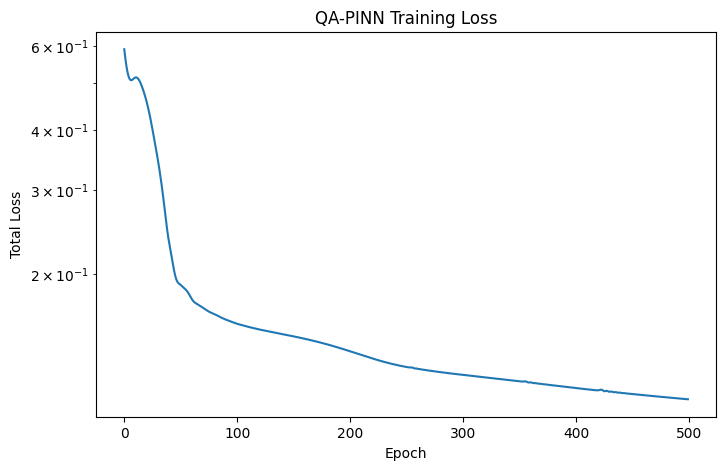

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("QA-PINN Training Loss")
plt.yscale("log")
plt.show()

Predictions on a test grid

In [ ]:
def predict(model, x, t):
    x_t = torch.tensor(x, dtype=torch.float32).view(-1,1)
    t_t = torch.tensor(t, dtype=torch.float32).view(-1,1)
    with torch.no_grad():
        return model(x_t, t_t).numpy().flatten()

x_test = np.linspace(x_min, x_max, 100)
t_test = np.linspace(t_min, t_max, 100)
X, T = np.meshgrid(x_test, t_test)
U_qapinn = predict(model, X.flatten(), T.flatten()).reshape(X.shape)

print("Prediction grid shape:", U_qapinn.shape)

Prediction grid shape: (100, 100)


Heatmap visualization

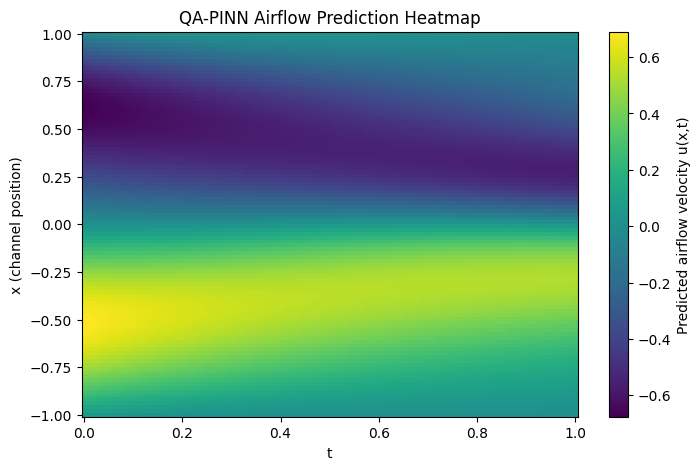

In [ ]:
plt.figure(figsize=(8,5))
plt.pcolormesh(t_test, x_test, U_qapinn.T, cmap='viridis', shading='auto')
plt.colorbar(label='Predicted airflow velocity u(x,t)')
plt.xlabel('t')
plt.ylabel('x (channel position)')
plt.title('QA-PINN Airflow Prediction Heatmap')
plt.show()

3D surface plot

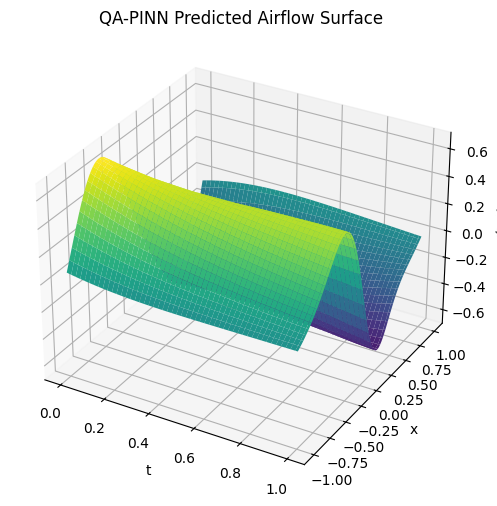

In [ ]:
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T, X, U_qapinn, cmap='viridis')
ax.set_xlabel('t')
ax.set_ylabel('x')
ax.set_zlabel('u(x,t)')
ax.set_title('QA-PINN Predicted Airflow Surface')
plt.show()

Compare with your classical PINN

In [ ]:
# Load or recompute your classical PINN predictions on the SAME x_test, t_test grid
# U_pinn = ... (100x100 array, same shape as U_qapinn)

def metrics(u_true, u_pred):
    u_true, u_pred = u_true.flatten(), u_pred.flatten()
    mse = mean_squared_error(u_true, u_pred)
    mae = mean_absolute_error(u_true, u_pred)
    r2  = r2_score(u_true, u_pred)
    return mse, mae, r2

# mse, mae, r2 = metrics(U_pinn, U_qapinn)
# print(f"MSE={mse:.6f}, MAE={mae:.6f}, R2={r2:.6f}")